In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
i = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        i +=1
        if i >= 10:
            break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_45.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_177.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_181.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_178.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_123.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_290.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_251.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_99.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_246.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import keras
from PIL import Image
from sklearn.neighbors import NearestNeighbors
# Ignore all warnings for teaching purpose
warnings.filterwarnings("ignore")

In [3]:
import glob

dataset_path = '/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/*/'
image_paths = []
for ext in ['*.jpg', '*.png', '*.jpeg', '*.JPG', '*.PNG']:
    image_paths.extend(glob.glob(dataset_path + ext))

len(image_paths)

490

In [4]:
image_paths[0]

'/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_45.jpg'

In [5]:
from tensorflow.keras.applications import MobileNetV2

backbone = MobileNetV2(
                        weights="imagenet",
                        include_top=False,
                        pooling="avg"
                      )

I0000 00:00:1786786011.733702      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786786011.736580      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
backbone.trainable = False  
backbone.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from tensorflow.keras.utils import load_img, img_to_array
from keras.applications.mobilenet import preprocess_input

def preprocess_img(img_path):
    
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    preprocessed_img = preprocess_input(img_array)
    
    return preprocessed_img

In [8]:
preprocessed_img = preprocess_img(image_paths[0])

preprocessed_img.shape

(224, 224, 3)

## embedding

In [9]:
def extract_embedding(img_path):
    preprocessed_img = preprocess_img(img_path)
    img = np.expand_dims(preprocessed_img, axis=0)
    embedding = backbone.predict(img, verbose=0)
    return embedding #.flatten()

In [10]:
extract_embedding(image_paths[0])

2026-08-15 09:27:04.280679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 09:27:04.428297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 09:27:04.564136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786786025.913686     154 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


array([[0.       , 1.8358603, 0.       , ..., 0.       , 0.       ,
        1.5509396]], dtype=float32)

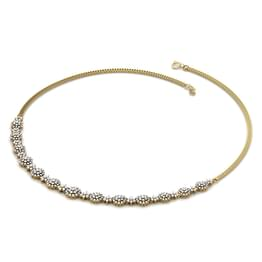

In [11]:
img1 = load_img(image_paths[0])
img1

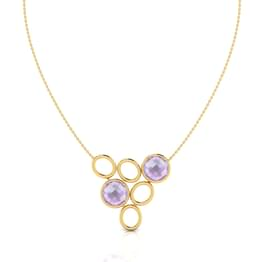

In [12]:
img2 = load_img(image_paths[1])
img2

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
embedding_img1 = extract_embedding(image_paths[0])
embedding_img2 = extract_embedding(image_paths[1])

cosine_similarity(embedding_img1, embedding_img2)

array([[0.6279882]], dtype=float32)

In [15]:
from tqdm import tqdm


feature_list = []

for img_path in tqdm(image_paths): 
    feature_list.append(extract_embedding(img_path))

# Convert to a numpy array for efficient searching
feature_list = np.squeeze(np.array(feature_list))

100%|██████████| 490/490 [00:44<00:00, 11.10it/s]


In [16]:
feature_list.shape

(490, 1280)

In [22]:
import pickle

payload_data = []

# استخدام قائمة المسارات الموجودة في كودك
for path in image_paths:  # أو image_paths بدون تحديد لو أردتِ الكل
  with open(path, 'rb') as f:
    img_bytes = f.read()
  payload_data.append(img_bytes)

payload = {'features': feature_list, 'images': payload_data}

with open('jewellery_metadata.pkl', 'wb') as f:
  pickle.dump(payload, f)

print('تم حفظ الصور والـ Features داخل الملف بنجاح! 🎉')

تم حفظ الصور والـ Features داخل الملف بنجاح! 🎉


In [20]:
import tf2onnx
import tensorflow as tf

# تحويل نموذج MobileNetV2 إلى صيغة ONNX الخفيفة
spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name="input"),)
output_path = "mobilenet.onnx"
model_proto, _ = tf2onnx.convert.from_keras(
    backbone, input_signature=spec, output_path=output_path
)
print("تم حفظ mobilenet.onnx بنجاح!")

I0000 00:00:1786788967.989373      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1786788967.989618      58 single_machine.cc:376] Starting new session
I0000 00:00:1786788968.004982      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786788968.006694      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1786788969.179771      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786788969.181491      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

تم حفظ mobilenet.onnx بنجاح!


In [19]:
!pip install tf2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 13.8 MB/s eta 0:00:00a 0:00:01
